# Importing libraries

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 8)
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn import metrics
from sklearn.utils import resample

# Splitting DataFrame based on clusters

In [42]:
cluster_1 = fen_df_mode[fen_df_mode['Clusters'] == 1]

In [43]:
cluster_2 = fen_df_mode[fen_df_mode['Clusters'] == 2]

In [44]:
cluster_3 = fen_df_mode[fen_df_mode['Clusters'] == 3]

In [45]:
cluster_4 = fen_df_mode[fen_df_mode['Clusters'] == 4]

In [46]:
clusters = [cluster_1, cluster_2, cluster_3, cluster_4]

for c in clusters:
    print(c['Death'].value_counts())
    c.reset_index(drop=True, inplace=True)

Accidental Drug Poisoning    30070
Other                         1970
Name: Death, dtype: int64
Accidental Drug Poisoning    11473
Other                          782
Name: Death, dtype: int64
Accidental Drug Poisoning    12064
Other                          835
Name: Death, dtype: int64
Accidental Drug Poisoning    14241
Other                          788
Name: Death, dtype: int64


# Cluster 1: RF Modeling/ OverSampling 45%/ Tuning.

In [250]:
cluster_1 = cluster_1.drop('Clusters', axis=1)
cluster_1.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning
1,High school graduate or GED completed,M,31 to 40,"Never married, single",Other/ Islanders,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning
2,Unknown,M,31 to 40,"Never married, single",Other/ Islanders,Construction & Extraction Occupations,Accidental Drug Poisoning
3,"9 - 12th grade, no diploma",F,31 to 40,Divorced,Other/ Islanders,"Other, Housewife",Accidental Drug Poisoning
4,High school graduate or GED completed,F,19 to 30,"Never married, single",White,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning


In [251]:
cluster_1 = pd.get_dummies(cluster_1, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation', 'Death'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation', 'dummy_death'])
cluster_1.head()

,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,dummy_sex_F,...,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown,dummy_death_Accidental Drug Poisoning,dummy_death_Other
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [252]:
# Death attribute has two values only so we can drop one of them since they are considered redundant. We are predicting Accidental or not, so only 1 column is suffice. 
cluster_1.drop('dummy_death_Other', axis=1, inplace=True)
cluster_1.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_1.drop('dummy_sex_F', axis=1, inplace=True)
#1 = Accidental, 0 = Other

In [253]:
clus_train, clus_test = train_test_split(cluster_1, test_size=0.25, random_state=34)
print(clus_train.shape)
print(clus_test.shape)

(24030, 53)
(8010, 53)


In [254]:
kfold = StratifiedKFold(n_splits= 10, shuffle=True, random_state=34)

In [255]:
print(clus_train["Death"].count())
print(clus_train["Death"].value_counts(normalize = True))
clus_train["Death"].value_counts()

24030
1    0.937703
0    0.062297
Name: Death, dtype: float64


1    22533
0     1497
Name: Death, dtype: int64

In [256]:
def determine_num_samples(records, unique_records, proportion):
    x = int((proportion * records - unique_records) / (1 - proportion))
    return x

In [257]:
num_samples_other_deaths = determine_num_samples(len(clus_train), 1497, 0.2)
print("Other Deaths Upsample samples to add: ", num_samples_other_deaths)

Other Deaths Upsample samples to add:  4136


In [258]:
to_resample = clus_train.loc[clus_train['Death'] == 0]

In [259]:
our_resample = to_resample.sample(n = 4136 , replace = True)
clus_train_rebal = pd.concat([clus_train, our_resample])

In [260]:
clus_train_rebal['Death'].value_counts()

1    22533
0     5633
Name: Death, dtype: int64

In [261]:
x_train = clus_train_rebal.drop('Death', axis=1)
y_train = clus_train_rebal['Death']

In [262]:
x_test = clus_test.drop('Death', axis=1)
y_test = clus_test['Death']

In [263]:
#Using CrossValidation for model selection: 
models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
               'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
               'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
               'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

model_cv_score = {}

for name, model in models_dict.items():
    score = cross_val_score(model, x_train, y_train, cv=kfold)
    model_cv_score[name] = score.mean()

print(f'Model Scores: {model_cv_score}\n')

Model Scores: {'RandomForest': 0.8238299402773743, 'NaiveBayes': 0.8006817375028238, 'XGBoost': 0.8118299609513666, 'Decision Tree': 0.8103033757099751}



In [137]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
params = {
    "n_estimators": [100, 200, 300, 400, 500],  # Number of trees in the forest
    "max_depth": [10, 15, 20, 30, 40],  # Maximum depth of the tree
    "min_samples_split": [2, 4, 6, 8, 10],  # Minimum number of samples required to split an internal node
    "criterion": ["gini", "entropy"],  # Function to measure the quality of a split
}

rf01 = GridSearchCV(RandomForestClassifier(), param_grid = params, cv = kfold, n_jobs = -1, verbose = 1)
rf01.fit(x_train, y_train)

print("Best Parameters : ", rf01.best_params_)
print("Best Accuracy through grid search : %.3f"%rf01.best_score_)

Fitting 10 folds for each of 250 candidates, totalling 2500 fits


KeyboardInterrupt: 

In [ ]:
print(f'Our baseline model is {y_train.value_counts(normalize = True)[0] * 100}% accurate')
print(f'Our baseline model based on the testing partition is {y_test.value_counts(normalize = True)[0] * 100}% accurate')

Our baseline model is 19.99928992402187% accurate
Our baseline model based on the testing partition is 5.905118601747815% accurate


In [265]:
rf02 = RandomForestClassifier(criterion = 'gini', max_depth = 40, min_samples_split = 2, n_estimators = 100, random_state=34, class_weight = 'balanced').fit(x_train, y_train)
rf02_score = cross_val_score(rf02, x_train, y_train, cv=kfold)

In [ ]:
print(f"Our CART Classification Decision Tree model with the best optimized parameters on the Testing set is : {rf02.score(x_test, y_test) * 100}% accurate")
print(f"Our CART Classification Decision model with the best optimal parameters with stratified k-fold cross validation on the training dataset is on average : {rf02_score.mean() * 100}% accurate")

Our CART Classification Decision Tree model with the best optimized parameters on the Testing set is : 67.71535580524345% accurate
Our CART Classification Decision model with the best optimal parameters with stratified k-fold cross validation on the training dataset is on average : 69.1685689260819% accurate


In [ ]:
prediction_rf = rf02.predict(x_test)

print("Classification Report")
print(classification_report(y_test, prediction_rf))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test, prediction_rf))
print("============")
print("Accuracy Score is : ", accuracy_score(prediction_rf, y_test))
print("==============")

test_predictions_proba = rf02.predict_proba(x_test)
ll = log_loss(y_test, test_predictions_proba)
print("Log Loss: {:.4}".format(ll))
print("===============")

Classification Report
              precision    recall  f1-score   support

           0       0.06      0.32      0.11       473
           1       0.94      0.70      0.80      7537

    accuracy                           0.68      8010
   macro avg       0.50      0.51      0.45      8010
weighted avg       0.89      0.68      0.76      8010

Confusion Matrix
[[ 152  321]
 [2265 5272]]
Accuracy Score is :  0.6771535580524345
Log Loss: 0.8011


# Cluster 1: RF Modeling (Oversample) & Categorical Target Feature. No tuning

In [269]:
cluster_1 = cluster_1.drop('Clusters', axis=1)
cluster_1.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
2,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning
5,High school graduate or GED completed,M,31 to 40,"Never married, single",Other/ Islanders,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning
6,Unknown,M,31 to 40,"Never married, single",Other/ Islanders,Construction & Extraction Occupations,Accidental Drug Poisoning
10,"9 - 12th grade, no diploma",F,31 to 40,Divorced,Other/ Islanders,"Other, Housewife",Accidental Drug Poisoning
14,High school graduate or GED completed,F,19 to 30,"Never married, single",White,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning


In [270]:
cluster_1 = pd.get_dummies(cluster_1, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation'])
cluster_1.head()

,Death,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,...,dummy_occupation_Military,dummy_occupation_Office & Administrative Support Occupations,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown
2,Accidental Drug Poisoning,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,Accidental Drug Poisoning,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Accidental Drug Poisoning,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
10,Accidental Drug Poisoning,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
14,Accidental Drug Poisoning,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [271]:
clus_train, clus_test = train_test_split(cluster_1, test_size=0.25, random_state=34)
print(clus_train.shape)
print(clus_test.shape)

(24030, 54)
(8010, 54)


In [272]:
kfold = StratifiedKFold(n_splits= 10, shuffle=True, random_state=34)

In [273]:
print(clus_train["Death"].count())
print(clus_train["Death"].value_counts(normalize = True))
clus_train["Death"].value_counts()

24030
Accidental Drug Poisoning    0.937703
Other                        0.062297
Name: Death, dtype: float64


Accidental Drug Poisoning    22533
Other                         1497
Name: Death, dtype: int64

In [274]:
def determine_num_samples(records, unique_records, proportion):
    x = int((proportion * records - unique_records) / (1 - proportion))
    return x

In [275]:
num_samples_other_deaths = determine_num_samples(len(clus_train), 1497, 0.45)
print("Other Deaths Upsample samples to add: ", num_samples_other_deaths)

Other Deaths Upsample samples to add:  16939


In [276]:
to_resample = clus_train.loc[clus_train['Death'] =='Other']

In [277]:
our_resample = to_resample.sample(n = 16939 , replace = True)
clus_train_rebal = pd.concat([clus_train, our_resample])

In [278]:
clus_train_rebal['Death'].value_counts()

Accidental Drug Poisoning    22533
Other                        18436
Name: Death, dtype: int64

In [279]:
x_train = clus_train_rebal.drop('Death', axis=1)
y_train = clus_train_rebal['Death']

In [280]:
x_test = clus_test.drop('Death', axis=1)
y_test = clus_test['Death']

In [ ]:
print(f'Our baseline model is {y_train.value_counts(normalize = True)[0] * 100}% accurate')
print(f'Our baseline model based on the testing partition is {y_test.value_counts(normalize = True)[0] * 100}% accurate')

Our baseline model is 55.000122043496305% accurate
Our baseline model based on the testing partition is 94.09488139825218% accurate


In [282]:
cart02 = RandomForestClassifier(criterion = 'gini', max_depth = 30, min_samples_split = 2, n_estimators = 300, 
                                random_state=34, class_weight = 'balanced').fit(x_train, y_train)
cart02_score = cross_val_score(cart02, x_train, y_train, cv=kfold)

In [ ]:
print(f"Our CART Classification Decision Tree model with the best optimized parameters on the Testing set is : {cart02.score(x_test, y_test) * 100}% accurate")
print(f"Our CART Classification Decision model with the best optimal parameters with stratified k-fold cross validation on the training dataset is on average : {cart02_score.mean() * 100}% accurate")

Our CART Classification Decision Tree model with the best optimized parameters on the Testing set is : 68.07740324594256% accurate
Our CART Classification Decision model with the best optimal parameters with stratified k-fold cross validation on the training dataset is on average : 69.71123533130186% accurate


In [ ]:
prediction_cart02 = cart02.predict(x_test)

print("Classification Report")
print(classification_report(y_test, prediction_cart02))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test, prediction_cart02))
print("============")
print("Accuracy Score is : ", accuracy_score(prediction_cart02, y_test))
print("==============")

test_predictions_proba = cart02.predict_proba(x_test)
ll = log_loss(y_test, test_predictions_proba)
print("Log Loss: {:.4}".format(ll))
print("===============")

Classification Report
                           precision    recall  f1-score   support

Accidental Drug Poisoning       0.94      0.70      0.81      7537
                    Other       0.07      0.33      0.11       473

                 accuracy                           0.68      8010
                macro avg       0.50      0.52      0.46      8010
             weighted avg       0.89      0.68      0.76      8010

Confusion Matrix
[[5297 2240]
 [ 317  156]]
Accuracy Score is :  0.6807740324594257
Log Loss: 0.6032


# Cluster 1: DecisionTree Modeling/ Tuning/ No oversampling:

In [290]:
cluster_1 = cluster_1.drop('Clusters', axis=1)
cluster_1.head()

,Education,Sex,AgeCategory,Marital Status,Race,Occupation,Death
0,"Some college credit, but no degree",M,31 to 40,"Never married, single",White,Management Occupations,Accidental Drug Poisoning
1,High school graduate or GED completed,M,31 to 40,"Never married, single",Other/ Islanders,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning
2,Unknown,M,31 to 40,"Never married, single",Other/ Islanders,Construction & Extraction Occupations,Accidental Drug Poisoning
3,"9 - 12th grade, no diploma",F,31 to 40,Divorced,Other/ Islanders,"Other, Housewife",Accidental Drug Poisoning
4,High school graduate or GED completed,F,19 to 30,"Never married, single",White,Food Preparation & Serving Related Occupations,Accidental Drug Poisoning


In [291]:
cluster_1 = pd.get_dummies(cluster_1, columns=['Education', 'Sex', 'AgeCategory', 'Marital Status', 'Race', 'Occupation'], prefix=['dummy_edu','dummy_sex','dummy_age', 'dummy_marital', 'dummy_race', 'dummy_occupation'])
cluster_1.head()

,Death,dummy_edu_8th grade or less,"dummy_edu_9 - 12th grade, no diploma",dummy_edu_Associate degree,dummy_edu_Bachelors degree,dummy_edu_Doctorate or professional degree,dummy_edu_High school graduate or GED completed,dummy_edu_Masters degree,"dummy_edu_Some college credit, but no degree",dummy_edu_Unknown,...,dummy_occupation_Military,dummy_occupation_Office & Administrative Support Occupations,"dummy_occupation_Other, Housewife","dummy_occupation_Other, Misc (exc Housewife)",dummy_occupation_Personal Care & Service Occupations,dummy_occupation_Production Occupations,dummy_occupation_Protective Service Occupations,dummy_occupation_Sales & Related Occupations,dummy_occupation_Transportation & Material Moving Occupations,dummy_occupation_Unknown
0,Accidental Drug Poisoning,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,Accidental Drug Poisoning,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Accidental Drug Poisoning,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,Accidental Drug Poisoning,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,Accidental Drug Poisoning,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [292]:
# Death attribute has two values only so we can drop one of them since they are considered redundant. We are predicting Accidental or not, so only 1 column is suffice. 
#cluster_1.drop('dummy_death_Other', axis=1, inplace=True)
#cluster_1.rename(columns={'dummy_death_Accidental Drug Poisoning': 'Death'}, inplace=True)
cluster_1.drop('dummy_sex_F', axis=1, inplace=True)
#1 = Accidental, 0 = Other

In [293]:
x = cluster_1.drop('Death', axis=1)
y = cluster_1['Death']

In [294]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=34, stratify = y) 
print(x_train.shape)
print(y_train.shape)

(24030, 52)
(24030,)


In [295]:
#OverSample 0/ Non-accidental deaths on y_train.
y_train.value_counts()

Accidental Drug Poisoning    22553
Other                         1477
Name: Death, dtype: int64

In [296]:
kfold = StratifiedKFold(n_splits= 10, shuffle=True, random_state=34)

In [297]:
#Using CrossValidation for model selection: 
models_dict = {'RandomForest': RandomForestClassifier(n_estimators = 10, criterion='gini', random_state = 34), 
               'NaiveBayes': MultinomialNB(alpha=1.0, fit_prior=True), 
               'XGBoost': XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
               'Decision Tree': DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=5, random_state = 34)}

model_cv_score = {}

for name, model in models_dict.items():
    score = cross_val_score(model, x_train, y_train, cv=kfold)
    model_cv_score[name] = score.mean()

print(f'Model Scores: {model_cv_score}\n')

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/aryan/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/aryan/.local/lib/python3.8/site-packages/xgboost/core.py", line 730, in inner_f
    return func(**kwargs)
  File "/home/aryan/.local/lib/python3.8/site-packages/xgboost/sklearn.py", line 1471, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['Accidental Drug Poisoning' 'Other']


In [ ]:
#We are going to use XGBoost or DecisionTree as they have the highest accuracies (using stratified k fold cv)
params = {"max_leaf_nodes": [2, 4, 8, 16, 32, 64, 100, 200],
          "max_depth": [10, 15, 20, 30, 40, 50, 60, 80, 100],
          "min_samples_split": [2, 3, 4, 5, 6, 7, 8, 9, 10],
          "criterion": ["gini", "entropy"]}


cart01 = GridSearchCV(DecisionTreeClassifier(), param_grid = params, cv = kfold, n_jobs = -1, verbose = 1)
cart01.fit(x_train, y_train)

print("Best Parameters : ", cart01.best_params_)
print("Best Accuracy through grid search : %.3f"%cart01.best_score_)

In [298]:
y_train.value_counts()

Accidental Drug Poisoning    22553
Other                         1477
Name: Death, dtype: int64

In [ ]:
print(f'Our baseline model is {y_train.value_counts(normalize = True)[0] * 100}% accurate')
print(f'Our baseline model based on the testing partition is {y_test.value_counts(normalize = True)[0] * 100}% accurate')

Our baseline model is 93.8535164377861% accurate
Our baseline model based on the testing partition is 93.84519350811486% accurate


In [300]:
cart02 = DecisionTreeClassifier(criterion = 'gini', max_depth = 10, max_leaf_nodes = 8, min_samples_split = 2, random_state=34).fit(x_train, y_train)
cart02_score = cross_val_score(cart02, x_train, y_train, cv=kfold)

In [ ]:
print(f"Our CART Classification Decision Tree model with the best optimized parameters on the Testing set is : {cart02.score(x_test, y_test) * 100}% accurate")
print(f"Our CART Classification Decision model with the best optimal parameters with stratified k-fold cross validation on the training dataset is on average : {cart02_score.mean() * 100}% accurate")

Our CART Classification Decision Tree model with the best optimized parameters on the Testing set is : 93.82022471910112% accurate
Our CART Classification Decision model with the best optimal parameters with stratified k-fold cross validation on the training dataset is on average : 94.0407823553891% accurate


In [ ]:
prediction_cart02 = cart02.predict(x_test)

print("Classification Report")
print(classification_report(y_test, prediction_cart02))
print("===========")
print("Confusion Matrix")
print(confusion_matrix(y_test, prediction_cart02))
print("============")
print("Accuracy Score is : ", accuracy_score(prediction_cart02, y_test))
print("==============")

test_predictions_proba = cart02.predict_proba(x_test)
ll = log_loss(y_test, test_predictions_proba)
print("Log Loss: {:.4}".format(ll))
print("===============")

Classification Report
                           precision    recall  f1-score   support

Accidental Drug Poisoning       0.94      1.00      0.97      7517
                    Other       0.48      0.04      0.08       493

                 accuracy                           0.94      8010
                macro avg       0.71      0.52      0.52      8010
             weighted avg       0.91      0.94      0.91      8010

Confusion Matrix
[[7493   24]
 [ 471   22]]
Accuracy Score is :  0.9382022471910112
Log Loss: 0.2315


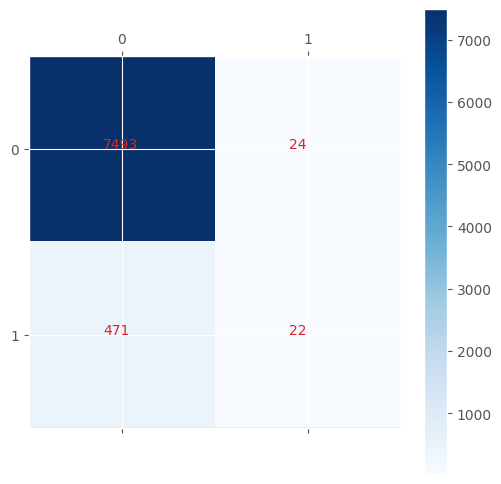

In [303]:
def plot_confusion_matrix(Y_test, Y_preds):
    conf_mat = confusion_matrix(Y_test, Y_preds)
    fig = plt.figure(figsize=(6,6))
    plt.matshow(conf_mat, cmap=plt.cm.Blues, fignum=1)
    plt.yticks(range(2), range(2))
    plt.xticks(range(2), range(2))
    plt.colorbar();
    for i in range(2):
        for j in range(2):
            plt.text(i-0.1,j, str(conf_mat[j, i]), color='tab:red')
    #plt.savefig('Cluster1ConfusionMatrix.png')
plot_confusion_matrix(y_test, prediction_cart02)

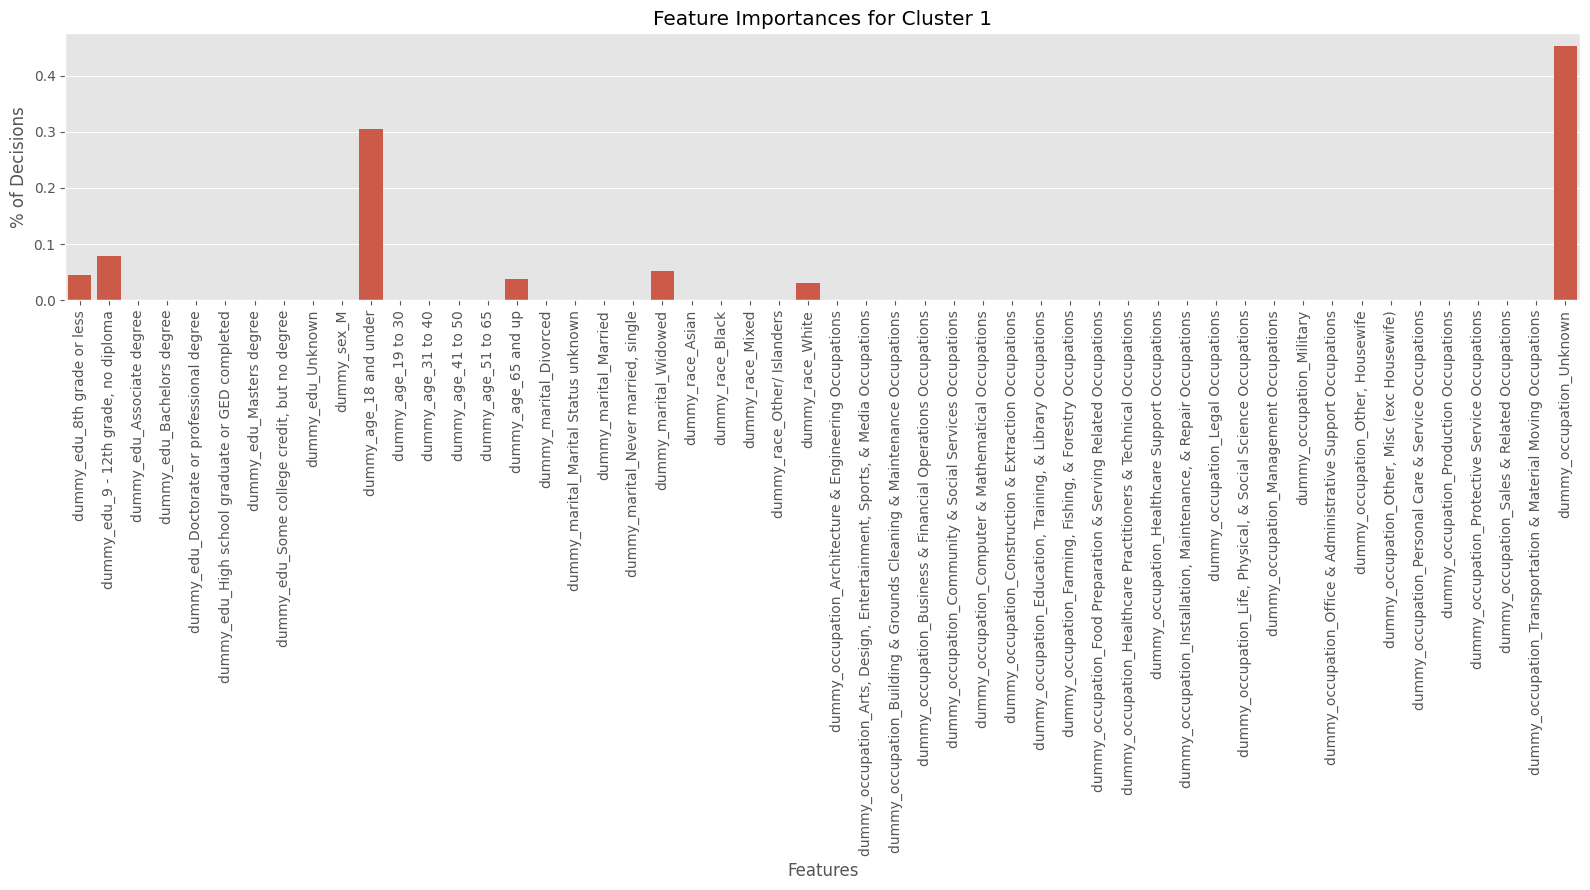

In [304]:
clus1_features = cart02.feature_importances_
def feature_importance(x, y, cluster):
    plt.figure(figsize = (16 , 9))
    sns.barplot(x = x.columns, y = y)
    plt.xlabel("Features")
    plt.xticks(rotation=90)
    plt.ylabel("% of Decisions")
    plt.title(f"Feature Importances for Cluster {cluster}")
    plt.tight_layout()
    #plt.savefig('Cluster1FeatureImportance.png')
    plt.show()
feature_importance(x_train, clus1_features, 1)